<a href="https://colab.research.google.com/github/MarioBetancourt04/Aprendizaje-Por-Refuerzo---Laboratorio-6/blob/main/Laboratorio6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***LABORATORIO 6 - POLICY GRADIENT METHODS***
En este cuadernillo de Python se resuelven los ejercicios de implementación del laboratorio 6 del curso de Aprendizaje por Refuerzo de la Universidad del Valle de Guatemala.

## **1) REINFORCE**
REINFORCE es un algoritmo de aprendizaje por gradiente de política que optimiza las decisiones de un agente mediante estimaciones de *Monte Carlo*. Este usa retornos de episodios completos.

El update de REINFORCE es:

$$\mathbb{\theta}_{t+1} =  \mathbb{\theta}_t + \alpha G_t \nabla \pi(A_t | S_t, \mathbb{\theta}_t)$$

Esta expresión se obtiene usando el teorema del gradiente de política, el cual establece que el gradiente de la medida de rendimiento $J(\mathbb{\theta})$ de una política $\pi_\mathbb{\theta}(s)$ parametrizada respecto a $\mathbb{\theta}$ puede calcularse sin diferenciar la política, usando una regla de proporcionalidad:

$$\nabla J(\mathbb{\theta}) \propto \sum_s \mu(s) \sum_a q_{\pi} (s,a) ∇ \pi(a|s,\mathbb{\theta}_t) $$

Donde $\mu(s)$ es una distribución on-policy bajo $\pi$, es una distribución que indica la cantidad de tiempo que el agente pasa en cada estado. Esto también puede escribirse en forma de un valor esperado:

$$\nabla J(\mathbb{\theta})  =  \mathbb{E}_\pi \left[ \sum_a q_{\pi} (s,a) ∇ \pi(a|s,\mathbb{\theta}_t) \right]$$

Para obtener el update de REINFORCE, la expresión de antes se modifica multiplicando y dividiendo entre $\pi$ para reemplazar la función de valor de acción por el retorno en el paso $t$ porque

$$\mathbb{E}_\pi [G_t|S_t,A_t] = q_\pi(St, A_t)$$

La nueva expresión es:

$$\nabla J(\mathbb{\theta})  =  \mathbb{E}_\pi \left[ G_t \frac{\nabla \pi(A_t|s,\mathbb{\theta}_t)}{ \pi(A_t|s,\mathbb{\theta}_t)}  \right]$$

La ventaja de utilizar esta forma es que el retorno es una cantidad que se puede *muestrear* durante cada paso $t$.

El paso de REINFORCE se obtiene al instanciar un algoritmo de gradient ascent estocástico.

### **PSEUDOCÓDIGO**

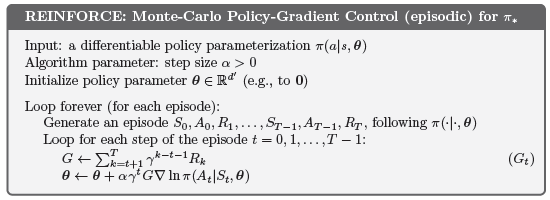

Un problema importante con esta implementación de Policy Gradient es que la varianza de $G_t$ es alta. Esto puede resolverse si se hace una comparación de la función de valor a una línea base (baseline) arbitraria.

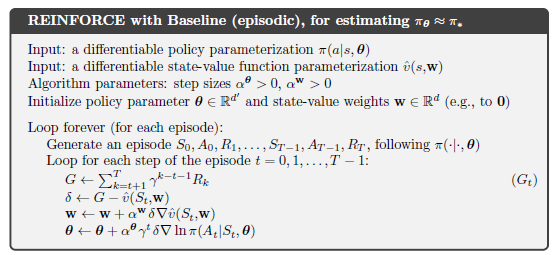

### **IMPLEMENTACIÓN**

Para implementar el algoritmo de aprendizaje REINFORCE con un baseline $V_\pi(s)$ calculan *ambas* la política $\pi(a,s|\mathbb{\theta})$ como la función de valor parametrizada $\hat{v}(s,\mathbb{w})$ a través de dos modelos de redes neuronales. Esto se hace porque *las redes neuronales pueden ser utilizadas como aproximadores de función universales*. Para ello se utiliza la librería PyTorch.

In [ ]:
# Importar librerías clave
import torch
import torch.nn as nn
import torch.functional as F
import gymnasium as gym

In [ ]:
class PolicyNetwork(nn.Module):
  """
  Aproximador de la política pi(a|s)
  usando redes neuronales.
  """
  def __init__(self, state_dim, action_dim):
    super().__init__()

    # Estructura de Red Neuronal
    # Input layer -> H1 (64 neuronas) -> H2 (64 neuronas) -> output layer
    self.fc1  = nn.Linear(state_dim)
    self.fc2  = nn.Linear(64,64)

    # Media - salida de la red con activación tanh
    self.mu_head  = nn.Linear(64, action_dim)

    # Desviación estándar - parámetro aprendible
    self.log_std = nn.Parameter(torch.log(torch.ones(action_dim) * 0.5))

    # se utiliza el logaritmo de la desviación estándar por dos razones
    # 1. evita que la red aprenda valores negativos de std
    # 2. estabilidad numérica

  def forward(self, x):
    """
    Forward propagation - mueve los datos de la input layer (x)
    hacia adelante en la red neuronal.
    - x : Input (un vector de dimensión state_dim)
    """
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    mu = torch.tanh(self.mu_head(x))
    std = torch.exp(self.log_std).expand_as(mu)

    return mu, std

In [ ]:
class ValueNetwork(nn.Module):
  """
  Aproximador de la función de valor V(s)
  usando redes neuronales.
  """
  def __init__(self, state_dim):
    super.__init__()
    self.fc1 = nn.Linear(state_dim, 64)
    self.fc2 = nn.Linear(64,64)
    self.v_head = nn.Linear(64,1)

  def forward(self, x):
    x = torch.relu(self.fc1(x))
    x = torch.relu(self.fc2(x))
    x = self.v_head(x)
    return x

In [ ]:
def compute_returns(rewards, gamma):
  """
  Produce una lista de retornos
  - rewards: Lista de recompensas
  - gamma: Factor de descuento
  """
  returns = []
  G = 0.0
  for r in reversed(rewards):
      G = r + gamma * G
      returns.insert(0, G)
  return returns

def get_grad_norm(params):
  """
  Calcula la norma euclidiana del gradiente
  - params: Lista de parámetros [Parameter]
  """
  total_norm = 0.0
  for p in params:
    if p.grad is not None:
      total_norm += p.grad.data.norm(2).item() ** 2
  return total_norm ** 0.5

In [ ]:
def train_REINFORCE(env : gym.Env, num_episodes, gamma, seed):
  """
  Función para entrenar
  - env : Entorno [Instancia de gym.Env]
  - num_episodes : Número de episodios a entrenar
  - gamma : Factor de descuento
  - seed : Semilla para generar números aleatorios
  """

  # Semilla para generar números aleatorios
  torch.manual_seed(seed)

  # Dimensiones de espacios de estados y de acciones
  state_dim = env.observation_space.shape[0]
  action_dim = env.action_space.shape[0]

  # Aproximadores de la política y la función de valor
  policy = PolicyNetwork(state_dim, action_dim)
  value = ValueNetwork(state_dim)

  # Optimizadores
  # Se utiliza el optimizador Adam con una tasa de aprendizaje de 0.001
  optimizer_policy = torch.optim.Adam(policy.parameters(), lr=0.001)
  optimizer_value = torch.optim.Adam(value.parameters(), lr=0.001)

  # Registro de datos
  episode_rewards = []
  grad_norms      = []
  entropies       = []

  # Iterar sobre todos los episodios
  for episode in range(num_episodes):
    state, info = env.reset(seed = seed + episode)

    # Registro de datos por episodio
    log_probs = []
    rewards = []
    states = []
    entropy_sum = 0.0

    # Variable de control
    done = False

    while not done:
      # -- MUESTREAR LA DISTRIBUCIÓN DE LA POLÍTICA --
      # Convertir el estado en un tensor
      state_tensor = torch.FloatTensor(state).unsqueeze(0)

      # Obtener la media y la desviación estandar con la red de la política
      mu, std = policy(state_tensor)
      dist = torch.distributions.Normal(mu, std)

      # Muestrear la distribución para obtener una acción
      action = dist.sample()

      # Calcular datos en el historial
      log_prob = dist.log_prob(action).sum()
      entropy_sum += dist.entropy().sum().item()

      # Truncar la acción entre -1.0 y 1.0
      action_clipped = torch.clamp(action, -1.0, 1.0).squeeze(0).numpy()

      # -- REALIZAR UNA TRANSICIÓN EN EL ENTORNO --
      next_state, reward, terminated, truncated, _ = env.step(action_clipped)
      done = terminated or truncated

      # -- MANTENER REGISTRO DE DATOS --
      log_probs.append(log_prob)
      rewards.append(reward)
      states.append(state_tensor)
      state = next_state

    # Calcular retornos
    returns = torch.FloatTensor(compute_returns(rewards, gamma))

    # Concatenar estados
    states_tensor = torch.cat(states)

    # Calcular valores usando estimador NN
    values = value(states_tensor).squeeze(-1)
    advantages = returns - values.detach()

    # --- Actualización de la política ---
    policy_loss = -torch.stack([lp * adv for lp, adv in zip(log_probs, advantages)]).sum()
    optimizer_policy.zero_grad()
    policy_loss.backward()
    grad_norm = get_grad_norm(policy.parameters())
    optimizer_policy.step()

    # --- Actualización de la función de valor ---
    value_loss = nn.functional.mse_loss(values, returns)
    optimizer_value.zero_grad()
    value_loss.backward()
    optimizer_value.step()

    # -- Recompensa total y entropia promedio --
    total_reward = sum(rewards)
    mean_entropy = entropy_sum / len(rewards)

    # -- Historial de datos --
    episode_rewards.append(total_reward)
    grad_norms.append(grad_norm)
    entropies.append(mean_entropy)

    if (episode + 1) % 50 == 0:
        print(f"REINFORCE | Episodio {episode+1} | Recompensa {total_reward:.2f}")

  return policy, value, episode_rewards, grad_norms, entropies

## **ACTOR-CRITIC**